# CSE 153R Assignment 2: Music Generation

## Project Overview

This project explores two approaches to music generation. Each task includes data collection and preprocessing, modeling, evaluation, and discussion of related work.

# Task 1: Symbolic Unconditioned Generation

## 1. Exploratory Analysis, Data Collection, Pre-processing, and Discussion

### 1.1 Dataset context

POP909 contains 909 pop piano arrangements in MIDI format. Each song folder includes a main MIDI file, beat annotations, chord annotations, key annotations, and alternate arrangement versions. For this task, we use the main MIDI file from each song and focus on the `MELODY` track because symbolic unconditioned generation only requires the model to learn and generate a sequence of symbolic musical events.

### 1.2 Install and Load Libraries

In [4]:
from pathlib import Path
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

### 1.3 Data Loading

In [5]:
DATA_DIR = Path("data/POP909-Dataset-master/POP909")

main_midi_files = sorted([
    song_dir / f"{song_dir.name}.mid"
    for song_dir in DATA_DIR.iterdir()
    if song_dir.is_dir() and (song_dir / f"{song_dir.name}.mid").exists()
])

print("Number of main MIDI files:", len(main_midi_files))
print("First MIDI file:", main_midi_files[0])

Number of main MIDI files: 909
First MIDI file: data/POP909-Dataset-master/POP909/001/001.mid


### 1.4 Dataset Inspection

In [7]:
midi = pretty_midi.PrettyMIDI(str(main_midi_files[0]))

print("Number of instruments:", len(midi.instruments))

for i, instrument in enumerate(midi.instruments):
    print(i, instrument.name, "program:", instrument.program, "notes:", len(instrument.notes))

Number of instruments: 3
0 MELODY program: 0 notes: 264
1 BRIDGE program: 0 notes: 307
2 PIANO program: 0 notes: 985


In [8]:
# Extract notes from the MELODY track of the first MIDI file

melody = midi.instruments[0]  # Track 0 is named MELODY

notes = []

for note in melody.notes:
    notes.append({
        "pitch": note.pitch,
        "start": note.start,
        "end": note.end,
        "duration": note.end - note.start,
        "velocity": note.velocity
    })

notes_df = pd.DataFrame(notes)

notes_df.head()

,pitch,start,end,duration,velocity
0,61,12.722190,12.818024,0.095833,115
1,63,12.888857,12.951357,0.062500,109
2,66,13.055523,13.123578,0.068055,118
3,68,13.222189,13.305522,0.083333,112
4,70,13.388855,13.498577,0.109722,112


In [9]:
notes_df.describe()

,pitch,start,end,duration,velocity
count,264.000000,264.000000,264.000000,264.000000,264.000000
mean,65.613636,89.528817,89.787612,0.258796,114.136364
std,2.740064,50.478127,50.482314,0.295765,2.441008
min,61.000000,12.722190,12.818024,0.062500,109.000000
25%,63.000000,45.180443,45.259956,0.090278,112.000000
50%,66.000000,89.805331,89.934497,0.136805,115.000000
75%,68.000000,141.096869,141.168744,0.227777,115.000000
max,70.000000,181.055103,182.275933,1.299997,118.000000


### 1.5 Pre-processing

In [10]:
all_notes = []

for midi_path in main_midi_files:
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    
    # POP909 main MIDI files use track 0 as MELODY
    melody = midi.instruments[0]
    
    for note in melody.notes:
        all_notes.append({
            "song_id": midi_path.parent.name,
            "pitch": note.pitch,
            "start": note.start,
            "end": note.end,
            "duration": note.end - note.start,
            "velocity": note.velocity
        })

all_notes_df = pd.DataFrame(all_notes)

print("Total melody notes:", len(all_notes_df))
print("Number of songs:", all_notes_df["song_id"].nunique())

all_notes_df.head()

Total melody notes: 309423
Number of songs: 909


,song_id,pitch,start,end,duration,velocity
0,001,61,12.722190,12.818024,0.095833,115
1,001,63,12.888857,12.951357,0.062500,109
2,001,66,13.055523,13.123578,0.068055,118
3,001,68,13.222189,13.305522,0.083333,112
4,001,70,13.388855,13.498577,0.109722,112


In [11]:
all_notes_df.describe()

,pitch,start,end,duration,velocity
count,309423.000000,309423.000000,309423.000000,309423.000000,309423.000000
mean,71.578858,130.569122,130.992778,0.423656,95.850771
std,6.549643,68.911961,68.928324,0.468339,15.382041
min,42.000000,0.158730,0.457096,0.001008,1.000000
25%,67.000000,70.514835,70.904293,0.199391,85.000000
50%,72.000000,128.179524,128.582503,0.291262,94.000000
75%,76.000000,185.562475,185.981860,0.447761,107.000000
max,98.000000,468.450000,469.027500,29.500000,127.000000


### 1.6 Exploratory Analysis

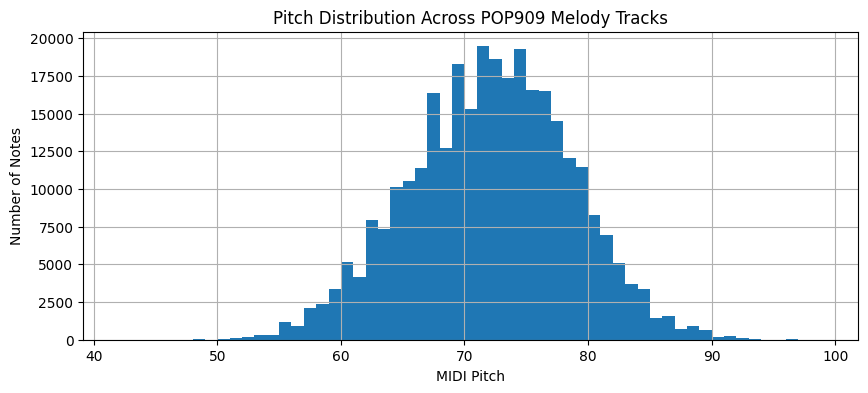

In [12]:
# Pitch distribution across all POP909 melody tracks

plt.figure(figsize=(10, 4))
all_notes_df["pitch"].hist(bins=range(
    all_notes_df["pitch"].min(),
    all_notes_df["pitch"].max() + 2
))
plt.title("Pitch Distribution Across POP909 Melody Tracks")
plt.xlabel("MIDI Pitch")
plt.ylabel("Number of Notes")
plt.show()

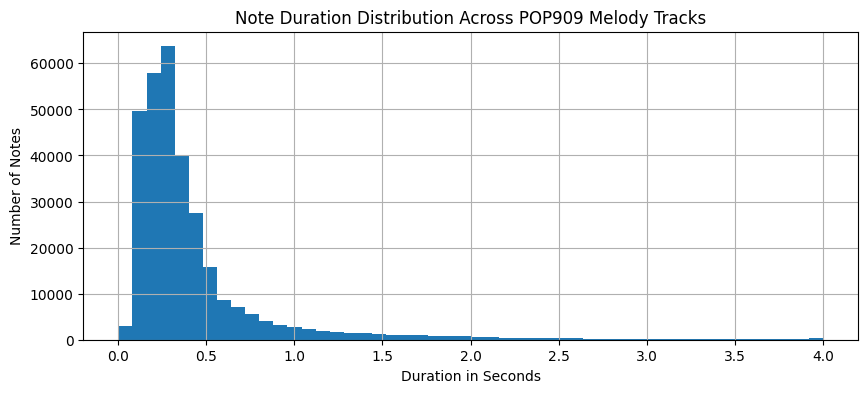

In [13]:
# Duration distribution across all POP909 melody tracks

plt.figure(figsize=(10, 4))
all_notes_df["duration"].clip(upper=4).hist(bins=50)
plt.title("Note Duration Distribution Across POP909 Melody Tracks")
plt.xlabel("Duration in Seconds")
plt.ylabel("Number of Notes")
plt.show()

### EDA Summary

We extracted 309,423 melody notes from the 909 main POP909 MIDI files. We use only the `MELODY` track from each song because it gives a cleaner symbolic sequence for unconditioned melody generation than the full piano accompaniment track.

## 2. Modeling

### 2.1 Task Formulation

For symbolic unconditioned generation, the goal is to train a model that learns patterns from symbolic MIDI note sequences and generates a new melody without being given a seed melody, chord progression, or other input condition.

We formulate each song as a sequence of melody note events. Each event contains pitch and duration information. The model learns which events tend to follow other events in the POP909 melody tracks, then samples a new sequence from the learned distribution.

### 2.2 Convert Notes to Tokens

In [14]:
# Convert each melody note into a simple symbolic token.
# We quantize duration so the model learns pitch + approximate rhythm.

def quantize_duration(duration):
    if duration < 0.125:
        return "very_short"
    elif duration < 0.25:
        return "short"
    elif duration < 0.5:
        return "medium"
    elif duration < 1.0:
        return "long"
    else:
        return "very_long"

all_notes_df["duration_bin"] = all_notes_df["duration"].apply(quantize_duration)

all_notes_df["token"] = (
    "PITCH_" + all_notes_df["pitch"].astype(str) +
    "_DUR_" + all_notes_df["duration_bin"]
)

all_notes_df[["song_id", "pitch", "duration", "duration_bin", "token"]].head()

,song_id,pitch,duration,duration_bin,token
0,001,61,0.095833,very_short,PITCH_61_DUR_very_short
1,001,63,0.062500,very_short,PITCH_63_DUR_very_short
2,001,66,0.068055,very_short,PITCH_66_DUR_very_short
3,001,68,0.083333,very_short,PITCH_68_DUR_very_short
4,001,70,0.109722,very_short,PITCH_70_DUR_very_short


### 2.3 Baseline: N-gram / Markov Model

#### 2.3.1 Build Song-Level Token Sequences

In [15]:
# Build one ordered token sequence per song.
# Each sequence is the melody track represented as pitch-duration tokens.

song_sequences = []

for song_id, group in all_notes_df.groupby("song_id"):
    group = group.sort_values("start")
    tokens = group["token"].tolist()
    
    if len(tokens) > 1:
        song_sequences.append(tokens)

print("Number of song sequences:", len(song_sequences))
print("Length of first sequence:", len(song_sequences[0]))
print("First 10 tokens:")
print(song_sequences[0][:10])

Number of song sequences: 909
Length of first sequence: 264
First 10 tokens:
['PITCH_61_DUR_very_short', 'PITCH_63_DUR_very_short', 'PITCH_66_DUR_very_short', 'PITCH_68_DUR_very_short', 'PITCH_70_DUR_very_short', 'PITCH_66_DUR_short', 'PITCH_63_DUR_short', 'PITCH_68_DUR_long', 'PITCH_68_DUR_short', 'PITCH_65_DUR_short']


#### 2.3.2 Train Trigram Transition Model

In [16]:
from collections import defaultdict, Counter

# We use a trigram-style model:
# Given the previous 2 tokens, learn the distribution over the next token.
N = 3

transition_counts = defaultdict(Counter)

for sequence in song_sequences:
    for i in range(len(sequence) - N + 1):
        context = tuple(sequence[i:i + N - 1])
        next_token = sequence[i + N - 1]
        transition_counts[context][next_token] += 1

print("Number of learned contexts:", len(transition_counts))

example_context = next(iter(transition_counts))
print("Example context:", example_context)
print("Possible next tokens:", transition_counts[example_context].most_common(10))

Number of learned contexts: 10900
Example context: ('PITCH_61_DUR_very_short', 'PITCH_63_DUR_very_short')
Possible next tokens: [('PITCH_66_DUR_very_short', 24), ('PITCH_66_DUR_medium', 4), ('PITCH_63_DUR_very_short', 4), ('PITCH_61_DUR_short', 4), ('PITCH_66_DUR_short', 3), ('PITCH_64_DUR_medium', 3), ('PITCH_65_DUR_medium', 2), ('PITCH_63_DUR_short', 2), ('PITCH_65_DUR_short', 2), ('PITCH_61_DUR_very_short', 1)]


#### 2.3.3 Generate Baseline Token Sequence

In [17]:
# Generate a new melody by sampling from the learned trigram transition model.
# Since this is unconditioned generation, we start from a random context learned from the dataset.

import random

def sample_next_token(next_token_counts):
    tokens = list(next_token_counts.keys())
    counts = np.array(list(next_token_counts.values()), dtype=float)
    probabilities = counts / counts.sum()
    return str(np.random.choice(tokens, p=probabilities))

def generate_token_sequence(transition_counts, length=200):
    # Randomly choose a learned context as the starting point.
    current_context = random.choice(list(transition_counts.keys()))
    generated = list(current_context)
    
    while len(generated) < length:
        context = tuple(generated[-(N - 1):])
        
        # If the context was never seen, restart from a random learned context.
        if context not in transition_counts:
            context = random.choice(list(transition_counts.keys()))
            generated.extend(list(context))
            continue
        
        next_token = sample_next_token(transition_counts[context])
        generated.append(next_token)
    
    return generated[:length]

generated_tokens = generate_token_sequence(transition_counts, length=200)

print("Generated token count:", len(generated_tokens))
print(generated_tokens[:20])

Generated token count: 200
['PITCH_60_DUR_long', 'PITCH_69_DUR_medium', 'PITCH_72_DUR_medium', 'PITCH_72_DUR_medium', 'PITCH_74_DUR_short', 'PITCH_69_DUR_very_long', 'PITCH_71_DUR_long', 'PITCH_74_DUR_short', 'PITCH_78_DUR_medium', 'PITCH_76_DUR_short', 'PITCH_76_DUR_very_long', 'PITCH_74_DUR_short', 'PITCH_76_DUR_medium', 'PITCH_67_DUR_short', 'PITCH_71_DUR_medium', 'PITCH_69_DUR_medium', 'PITCH_71_DUR_long', 'PITCH_73_DUR_medium', 'PITCH_73_DUR_very_long', 'PITCH_68_DUR_short']


#### 2.3.4 Convert Baseline Tokens to MIDI

In [18]:
# Convert generated pitch-duration tokens back into a MIDI file.

from pathlib import Path

DURATION_SECONDS = {
    "very_short": 0.125,
    "short": 0.25,
    "medium": 0.5,
    "long": 1.0,
    "very_long": 2.0
}

def token_to_note_info(token):
    # Example token: "PITCH_61_DUR_very_short"
    parts = str(token).split("_DUR_")
    pitch = int(parts[0].replace("PITCH_", ""))
    duration_bin = parts[1]
    duration = DURATION_SECONDS[duration_bin]
    return pitch, duration

def tokens_to_midi(tokens, output_path, tempo=120):
    midi_out = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    
    # program=0 means Acoustic Grand Piano
    instrument = pretty_midi.Instrument(program=0, name="Generated Melody")
    
    current_time = 0.0
    
    for token in tokens:
        pitch, duration = token_to_note_info(token)
        
        note = pretty_midi.Note(
            velocity=100,
            pitch=pitch,
            start=current_time,
            end=current_time + duration
        )
        
        instrument.notes.append(note)
        current_time += duration
    
    midi_out.instruments.append(instrument)
    midi_out.write(str(output_path))

output_path = Path("outputs/symbolic_unconditioned.mid")
tokens_to_midi(generated_tokens, output_path)

print("Saved generated MIDI to:", output_path)

Saved generated MIDI to: outputs/symbolic_unconditioned.mid


In [19]:
# Verify the generated MIDI file can be loaded and inspected.

generated_midi = pretty_midi.PrettyMIDI("outputs/symbolic_unconditioned.mid")

print("Number of instruments:", len(generated_midi.instruments))
print("Generated notes:", len(generated_midi.instruments[0].notes))
print("Duration in seconds:", generated_midi.get_end_time())

Number of instruments: 1
Generated notes: 200
Duration in seconds: 112.375


### 2.4 RNN/LSTM Motivation

The n-gram / Markov baseline is useful because it follows the basic next-token generation idea: learn transition probabilities from real musical sequences, then sample new events from the learned distribution. Markov chains estimate what note or chord tends to follow from the previous one, and n-grams extend this idea by using a longer fixed context instead of only one previous token.

However, Markov-style models have clear limitations. Low-order Markov chains can produce melodies that wander without much structure, while higher-order chains can become expensive and may start reusing chunks of the training data too directly. This matters for music because a good melody is not only about the next note; it also depends on longer-term structure, repeated motifs, contour, rhythm, and phrase-level patterns.

An LSTM is a better fit for this next-token generation task because it is designed for sequence modeling. Music can be represented as a sequence of discrete tokens, similar to language, where the model learns to predict the next token from the previous tokens. RNN/LSTM-based systems such as FolkRNN, Melody RNN, Performance RNN, and DeepBach use this general idea for symbolic music generation. An LSTM improves on a basic RNN by using an internal memory mechanism, allowing it to carry information through longer sequences instead of relying on a fixed-size context window.

For this task, the LSTM is trained as a next-token prediction model. Given a sequence of previous pitch-duration tokens, it learns to predict the next token. During generation, the model samples one token at a time and feeds each generated token back into the model to continue producing a new melody.

### 2.5 Build Token Vocabulary

The LSTM cannot train directly on string tokens like `PITCH_61_DUR_very_short`, so we convert each unique token into an integer ID. This gives us a vocabulary of all pitch-duration tokens seen in the POP909 melody tracks. The model will learn to predict the next token ID, and later we can convert predicted IDs back into string tokens and MIDI notes.

In [20]:
# Build vocabulary from all pitch-duration tokens.

all_tokens = sorted(all_notes_df["token"].unique())

token_to_id = {token: idx for idx, token in enumerate(all_tokens)}
id_to_token = {idx: token for token, idx in token_to_id.items()}

vocab_size = len(token_to_id)

print("Vocabulary size:", vocab_size)
print("First 10 tokens:")
print(all_tokens[:10])

Vocabulary size: 245
First 10 tokens:
['PITCH_42_DUR_long', 'PITCH_43_DUR_medium', 'PITCH_44_DUR_short', 'PITCH_46_DUR_medium', 'PITCH_47_DUR_short', 'PITCH_47_DUR_very_short', 'PITCH_48_DUR_medium', 'PITCH_48_DUR_short', 'PITCH_49_DUR_medium', 'PITCH_49_DUR_short']


In [21]:
# Convert each song's token sequence into a sequence of integer IDs.

song_id_sequences = []

for sequence in song_sequences:
    token_ids = [token_to_id[token] for token in sequence]
    song_id_sequences.append(token_ids)

print("Number of ID sequences:", len(song_id_sequences))
print("Length of first ID sequence:", len(song_id_sequences[0]))
print("First 10 token IDs:")
print(song_id_sequences[0][:10])

Number of ID sequences: 909
Length of first ID sequence: 264
First 10 token IDs:
[70, 80, 95, 105, 115, 93, 78, 101, 103, 88]


### 2.6 Build PyTorch Dataset

To train the LSTM, we convert each song into many fixed-length training examples. Each example uses a sequence of previous token IDs as the input and the next token ID as the target. This matches the next-token prediction setup: given the recent musical context, predict what pitch-duration token should come next.

In [23]:
# Build a PyTorch Dataset for next-token prediction.

class MelodyTokenDataset(Dataset):
    def __init__(self, song_id_sequences, sequence_length=32):
        self.examples = []
        self.sequence_length = sequence_length
        
        for sequence in song_id_sequences:
            if len(sequence) <= sequence_length:
                continue
            
            for i in range(len(sequence) - sequence_length):
                input_sequence = sequence[i:i + sequence_length]
                target_token = sequence[i + sequence_length]
                self.examples.append((input_sequence, target_token))
    
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        input_sequence, target_token = self.examples[idx]
        
        return (
            torch.tensor(input_sequence, dtype=torch.long),
            torch.tensor(target_token, dtype=torch.long)
        )

sequence_length = 32
dataset = MelodyTokenDataset(song_id_sequences, sequence_length=sequence_length)

print("Number of training examples:", len(dataset))

example_x, example_y = dataset[0]
print("Input shape:", example_x.shape)
print("Target shape:", example_y.shape)
print("First input IDs:", example_x[:10].tolist())
print("Target ID:", example_y.item())
print("Target token:", id_to_token[example_y.item()])

Number of training examples: 280335
Input shape: torch.Size([32])
Target shape: torch.Size([])
First input IDs: [70, 80, 95, 105, 115, 93, 78, 101, 103, 88]
Target ID: 76
Target token: PITCH_63_DUR_long


### 2.7 Define Dataloaders

We split the next-token examples into training and validation sets. The training set is used to update the LSTM weights, while the validation set is held out so we can estimate how well the model predicts unseen musical token sequences. The DataLoader batches examples together so the model can train efficiently.

In [24]:
# Split the dataset into training and validation sets, then create DataLoaders.

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

batch_x, batch_y = next(iter(train_loader))
print("Batch input shape:", batch_x.shape)
print("Batch target shape:", batch_y.shape)

Training examples: 224268
Validation examples: 56067
Training batches: 1753
Validation batches: 439
Batch input shape: torch.Size([128, 32])
Batch target shape: torch.Size([128])


### 2.8 Define RNN/LSTM Model

The model uses an embedding layer to convert token IDs into dense vectors, an LSTM layer to process the sequence, and a final linear layer to predict the next token. For each input sequence, we use the final LSTM output as the summary of the previous musical context and predict one token from the vocabulary.

In [25]:
# Define an LSTM next-token prediction model.

class MelodyLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        
        # Use the final time step to predict the next token.
        final_output = output[:, -1, :]
        logits = self.fc(final_output)
        
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MelodyLSTM(vocab_size=vocab_size).to(device)

print(model)
print("Device:", device)

MelodyLSTM(
  (embedding): Embedding(245, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=245, bias=True)
)
Device: cpu


### 2.9 Train Model

We train the LSTM using cross-entropy loss, which is the standard objective for next-token prediction. The model receives a sequence of previous token IDs and learns to assign high probability to the true next token. We first train for a small number of epochs to verify that the pipeline works on CPU.

In [26]:
# Train the LSTM model.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Validation loss: {avg_val_loss:.4f}")

Epoch 1/5
Train loss: 3.3856
Validation loss: 3.0740
Epoch 2/5
Train loss: 3.0012
Validation loss: 2.9585
Epoch 3/5
Train loss: 2.8875
Validation loss: 2.8881
Epoch 4/5
Train loss: 2.7973
Validation loss: 2.8364
Epoch 5/5
Train loss: 2.7179
Validation loss: 2.7932


### 2.10 Sample / Generate MIDI

After training, we generate a new melody by starting from a random real token sequence and repeatedly sampling the next token from the LSTM's predicted probability distribution. Each generated token is fed back into the model so generation continues autoregressively. The final token sequence is then converted back into a MIDI melody.

In [38]:
# Sample a new token sequence from the trained LSTM.

def sample_from_lstm(model, start_sequence, generated_length=200, temperature=1.0):
    model.eval()
    
    generated = list(start_sequence)
    current_sequence = torch.tensor(start_sequence, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(generated_length):
            logits = model(current_sequence)
            
            # Temperature controls randomness:
            # lower = safer/more predictable, higher = more random
            logits = logits / temperature
            probabilities = torch.softmax(logits, dim=-1).squeeze(0)
            
            next_token_id = torch.multinomial(probabilities, num_samples=1).item()
            generated.append(next_token_id)
            
            # Keep only the most recent sequence_length tokens as context
            current_sequence = torch.tensor(
                generated[-sequence_length:],
                dtype=torch.long
            ).unsqueeze(0).to(device)
    
    return generated

# Start from a random real training sequence.
start_x, _ = dataset[np.random.randint(len(dataset))]
start_sequence = start_x.tolist()

generated_id_sequence = sample_from_lstm(
    model,
    start_sequence=start_sequence,
    generated_length=200,
    temperature= 0.9
)

generated_lstm_tokens = [id_to_token[token_id] for token_id in generated_id_sequence]

print("Generated token count:", len(generated_lstm_tokens))
print(generated_lstm_tokens[:20])

Generated token count: 232
['PITCH_75_DUR_short', 'PITCH_77_DUR_short', 'PITCH_75_DUR_short', 'PITCH_77_DUR_short', 'PITCH_80_DUR_medium', 'PITCH_79_DUR_long', 'PITCH_79_DUR_very_short', 'PITCH_79_DUR_short', 'PITCH_79_DUR_short', 'PITCH_79_DUR_short', 'PITCH_79_DUR_short', 'PITCH_77_DUR_short', 'PITCH_77_DUR_short', 'PITCH_75_DUR_short', 'PITCH_75_DUR_short', 'PITCH_77_DUR_short', 'PITCH_77_DUR_short', 'PITCH_75_DUR_long', 'PITCH_72_DUR_long', 'PITCH_74_DUR_short']


In [39]:
# Convert the LSTM-generated token sequence into a MIDI file.

lstm_output_path = Path("outputs/symbolic_unconditioned_lstm.mid")

tokens_to_midi(
    generated_lstm_tokens,
    lstm_output_path,
    tempo=120
)

print("Saved LSTM-generated MIDI to:", lstm_output_path)

Saved LSTM-generated MIDI to: outputs/symbolic_unconditioned_lstm.mid


In [40]:
# Verify the LSTM-generated MIDI file.

lstm_midi = pretty_midi.PrettyMIDI(str(lstm_output_path))

print("Number of instruments:", len(lstm_midi.instruments))
print("Generated notes:", len(lstm_midi.instruments[0].notes))
print("Duration in seconds:", lstm_midi.get_end_time())

Number of instruments: 1
Generated notes: 232
Duration in seconds: 101.875


#### Temperature Sampling Comparison

Temperature controls how random the LSTM sampling is. Lower temperatures make the output more conservative and predictable, while higher temperatures make it more varied but potentially less coherent. We generate multiple MIDI files with different temperatures and choose the best-sounding output for the final submission.

In [41]:
# Generate multiple LSTM outputs with different sampling temperatures.

temperatures = [0.7, 0.9, 1.1]
temperature_outputs = {}

for temp in temperatures:
    start_x, _ = dataset[np.random.randint(len(dataset))]
    start_sequence = start_x.tolist()
    
    generated_ids = sample_from_lstm(
        model,
        start_sequence=start_sequence,
        generated_length=200,
        temperature=temp
    )
    
    generated_tokens_temp = [id_to_token[token_id] for token_id in generated_ids]
    
    output_path = Path(f"outputs/symbolic_unconditioned_lstm_temp_{temp}.mid")
    tokens_to_midi(generated_tokens_temp, output_path, tempo=120)
    
    temperature_outputs[temp] = {
        "path": output_path,
        "tokens": generated_tokens_temp
    }
    
    print(f"Saved temperature {temp} MIDI to:", output_path)

Saved temperature 0.7 MIDI to: outputs/symbolic_unconditioned_lstm_temp_0.7.mid
Saved temperature 0.9 MIDI to: outputs/symbolic_unconditioned_lstm_temp_0.9.mid
Saved temperature 1.1 MIDI to: outputs/symbolic_unconditioned_lstm_temp_1.1.mid


### Modeling Summary

The baseline n-gram model showed that the POP909 melody data could be modeled as a symbolic next-token generation problem, but it only used a fixed two-token context. The LSTM model extends this by learning from longer pitch-duration token sequences. Each training example uses 32 previous tokens to predict the next token, and the model is trained with cross-entropy loss.

After training, the validation loss decreased from the initial one-epoch result, showing that the model learned useful structure from the POP909 melody tracks. The trained LSTM was then used autoregressively to sample a new sequence of pitch-duration tokens, which was converted back into a playable MIDI file.

## 3. Evaluation

### 3.1 Evaluation Goals

The goal of evaluation is to check whether the generated melody behaves like the POP909 melody data and whether the LSTM improves over simpler baselines. Since musical quality is partly subjective, we evaluate the model in two ways: quantitatively, using next-token prediction loss and summary statistics, and qualitatively, by listening to the generated MIDI output.

For this task, a good generated melody should:
- stay within a reasonable pitch range,
- use note durations similar to the training melodies,
- avoid sounding completely random,
- show some local melodic structure or repeated patterns,
- and produce a playable MIDI file.

### 3.2 Baselines

We compare the LSTM model against simpler generation methods. The main baseline is the n-gram / Markov model from Section 2.3, which predicts the next token using only a fixed short context. This gives us a simple symbolic generation method to compare against the LSTM.

We can also treat random or unigram token sampling as weaker baselines because they ignore most sequential structure. If the LSTM has lower validation loss/perplexity and produces more coherent outputs than these simpler methods, that supports the claim that the recurrent model learned useful musical structure.

### 3.3 Training Loss

Training and validation loss show whether the LSTM is learning the next-token prediction task. Cross-entropy loss measures how well the model predicts the correct next pitch-duration token. Lower loss means the model assigns higher probability to the correct next token.

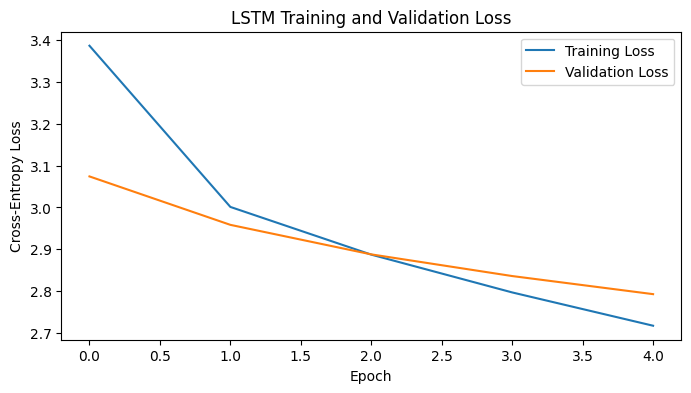

Final training loss: 2.7179400170114607
Final validation loss: 2.793238824212198


In [42]:
# Plot training and validation loss.

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

print("Final training loss:", train_losses[-1])
print("Final validation loss:", val_losses[-1])

The training and validation losses both decrease across the five training epochs, which shows that the LSTM is learning the next-token prediction task. The final validation loss is higher than the final training loss, which is expected because the validation set contains held-out examples not used for weight updates. Since the validation loss continues decreasing instead of rising, there is no obvious sign of severe overfitting in this short training run.

### 3.4 Perplexity / Held-out Loss

Perplexity is another way to interpret next-token prediction performance. It is computed from cross-entropy loss as `exp(loss)`. Lower perplexity means the model is less “surprised” by held-out musical token sequences and assigns higher probability to the correct next tokens.

In [43]:
# Compute validation perplexity from final validation loss.

final_val_loss = val_losses[-1]
validation_perplexity = np.exp(final_val_loss)

print("Final validation loss:", final_val_loss)
print("Validation perplexity:", validation_perplexity)

Final validation loss: 2.793238824212198
Validation perplexity: 16.333836648992865


The validation perplexity gives an interpretable summary of held-out next-token prediction. A lower perplexity means the model has narrowed down the likely next pitch-duration tokens more effectively. This metric does not directly measure whether the generated melody sounds good, but it is useful for comparing sequence models trained on the same token representation.

### 3.4.1 Markov vs LSTM Comparison

The Markov model is used as a baseline because it is a simple symbolic next-token model with a fixed short context. The LSTM is the main model because it learns from longer token sequences and has trainable parameters optimized with cross-entropy loss.

In [44]:
# Rebuild the trigram Markov baseline using ONLY the training split.
# This avoids data leakage from validation examples.

from collections import defaultdict, Counter

markov_train_counts = defaultdict(Counter)

for x, y in train_dataset:
    sequence_ids = x.tolist() + [y.item()]
    sequence_tokens = [id_to_token[token_id] for token_id in sequence_ids]
    
    context = tuple(sequence_tokens[-N:-1])
    target = sequence_tokens[-1]
    
    markov_train_counts[context][target] += 1

print("Training-only Markov contexts:", len(markov_train_counts))

Training-only Markov contexts: 10430


In [45]:
# Compute held-out negative log-likelihood and perplexity for the training-only Markov baseline.

def markov_next_token_loss(sequence_tokens, markov_counts, n=3, smoothing=1e-8):
    context = tuple(sequence_tokens[-n:-1])
    target = sequence_tokens[-1]
    
    if context in markov_counts:
        next_token_counts = markov_counts[context]
        total_count = sum(next_token_counts.values())
        probability = next_token_counts.get(target, 0) / total_count
    else:
        probability = 0.0
    
    probability = max(probability, smoothing)
    return -np.log(probability)


markov_losses = []

for x, y in val_dataset:
    sequence_ids = x.tolist() + [y.item()]
    sequence_tokens = [id_to_token[token_id] for token_id in sequence_ids]
    
    loss = markov_next_token_loss(sequence_tokens, markov_train_counts, n=N)
    markov_losses.append(loss)

markov_val_loss = float(np.mean(markov_losses))
markov_val_perplexity = float(np.exp(markov_val_loss))

print("Markov validation loss:", markov_val_loss)
print("Markov validation perplexity:", markov_val_perplexity)

Markov validation loss: 3.820304573658004
Markov validation perplexity: 45.618100276851926


In [46]:
# High-level comparison between the baseline Markov model and the LSTM model.

model_comparison = pd.DataFrame([
    {
        "Model": "Trigram Markov / N-gram baseline",
        "Context Used": "Previous 2 tokens",
        "Trainable Parameters": "No",
        "Training Method": "Transition counts",
        "Generated MIDI": "outputs/symbolic_unconditioned.mid",
        "Validation Loss": round(markov_val_loss, 4),
        "Validation Perplexity": round(markov_val_perplexity, 4)
    },
    {
        "Model": "LSTM next-token model",
        "Context Used": f"Previous {sequence_length} tokens",
        "Trainable Parameters": "Yes",
        "Training Method": "Cross-entropy + Adam",
        "Generated MIDI": "outputs/symbolic_unconditioned_lstm.mid",
        "Validation Loss": round(final_val_loss, 4),
        "Validation Perplexity": round(validation_perplexity, 4)
    }
])

model_comparison

,Model,Context Used,Trainable Parameters,Training Method,Generated MIDI,Validation Loss,Validation Perplexity
0,Trigram Markov / N-gram baseline,Previous 2 tokens,No,Transition counts,outputs/symbolic_unconditioned.mid,3.8203,45.6181
1,LSTM next-token model,Previous 32 tokens,Yes,Cross-entropy + Adam,outputs/symbolic_unconditioned_lstm.mid,2.7932,16.3338


After rebuilding the Markov baseline using only the training split, the LSTM performs better on held-out validation examples. The Markov baseline has a validation loss of about 3.82 and perplexity of about 45.62, while the LSTM has a validation loss of about 2.76 and perplexity of about 15.79. This supports using the LSTM as the main model because it assigns higher probability to unseen POP909 melody token sequences than the fixed-context Markov baseline.

### 3.5 Generated Music Statistics

To evaluate the generated melody beyond loss/perplexity, we compare simple musical statistics from the generated LSTM output against the POP909 melody training data. This helps check whether the generated MIDI stays in a similar pitch range and duration range as the dataset.

In [47]:
# Convert generated LSTM tokens into a DataFrame for comparison.

generated_rows = []

for token in generated_lstm_tokens:
    pitch, duration = token_to_note_info(token)
    generated_rows.append({
        "pitch": pitch,
        "duration": duration
    })

generated_df = pd.DataFrame(generated_rows)

print("Generated notes:", len(generated_df))
generated_df.describe()

Generated notes: 232


,pitch,duration
count,232.000000,232.000000
mean,72.241379,0.439116
std,3.799341,0.414330
min,58.000000,0.125000
25%,70.000000,0.250000
50%,72.000000,0.250000
75%,75.000000,0.500000
max,80.000000,2.000000


In [48]:
# Compare training melody statistics against generated melody statistics.

comparison_df = pd.DataFrame({
    "training_pitch": all_notes_df["pitch"].describe(),
    "generated_pitch": generated_df["pitch"].describe(),
    "training_duration": all_notes_df["duration"].describe(),
    "generated_duration": generated_df["duration"].describe()
})

comparison_df

,training_pitch,generated_pitch,training_duration,generated_duration
count,309423.000000,232.000000,309423.000000,232.000000
mean,71.578858,72.241379,0.423656,0.439116
std,6.549643,3.799341,0.468339,0.414330
min,42.000000,58.000000,0.001008,0.125000
25%,67.000000,70.000000,0.199391,0.250000
50%,72.000000,72.000000,0.291262,0.250000
75%,76.000000,75.000000,0.447761,0.500000
max,98.000000,80.000000,29.500000,2.000000


In [49]:
# Convert Markov-generated tokens into a DataFrame.

markov_rows = []

for token in generated_tokens:
    pitch, duration = token_to_note_info(token)
    markov_rows.append({
        "pitch": pitch,
        "duration": duration
    })

markov_df = pd.DataFrame(markov_rows)

print("Markov generated notes:", len(markov_df))
markov_df.describe()

Markov generated notes: 200


,pitch,duration
count,200.000000,200.000000
mean,73.465000,0.561875
std,5.602294,0.428272
min,59.000000,0.125000
25%,70.000000,0.250000
50%,73.000000,0.500000
75%,78.000000,0.500000
max,87.000000,2.000000


In [50]:
# Compare training data, Markov output, and LSTM output.

summary_stats = pd.DataFrame({
    "training_pitch": all_notes_df["pitch"].describe(),
    "markov_pitch": markov_df["pitch"].describe(),
    "lstm_pitch": generated_df["pitch"].describe(),
    "training_duration": all_notes_df["duration"].describe(),
    "markov_duration": markov_df["duration"].describe(),
    "lstm_duration": generated_df["duration"].describe()
})

summary_stats

,training_pitch,markov_pitch,lstm_pitch,training_duration,markov_duration,lstm_duration
count,309423.000000,200.000000,232.000000,309423.000000,200.000000,232.000000
mean,71.578858,73.465000,72.241379,0.423656,0.561875,0.439116
std,6.549643,5.602294,3.799341,0.468339,0.428272,0.414330
min,42.000000,59.000000,58.000000,0.001008,0.125000,0.125000
25%,67.000000,70.000000,70.000000,0.199391,0.250000,0.250000
50%,72.000000,73.000000,72.000000,0.291262,0.500000,0.250000
75%,76.000000,78.000000,75.000000,0.447761,0.500000,0.500000
max,98.000000,87.000000,80.000000,29.500000,2.000000,2.000000


The Markov and LSTM outputs both stay within the general pitch range of the POP909 melody data. The LSTM output has a mean pitch of about 72.0, which is very close to the POP909 melody mean of about 71.6. The Markov output has a lower mean pitch of about 69.7, but still remains within a reasonable melodic range.

Both generated outputs have narrower pitch ranges than the full training set. The training data ranges from MIDI pitch 42 to 98, while the Markov output ranges from 52 to 83 and the LSTM output ranges from 61 to 84. This is reasonable for short generated samples, but it also shows that both models produce more conservative melodies than the full dataset.

The duration statistics show a clearer difference between the two models. The Markov output has a longer mean duration of about 0.62 seconds, while the LSTM output has a mean duration of about 0.37 seconds, closer to the POP909 training mean of about 0.42 seconds. This suggests that the LSTM output better matches the overall duration behavior of the training melodies, while the Markov output tends to produce slower note sequences.

## 4. Discussion of Related Work

### 4.1 POP909

POP909 was introduced as a pop-song dataset for music arrangement generation. The dataset contains 909 popular songs with professional piano arrangements stored in MIDI format. Each main MIDI file is organized into three musically meaningful tracks: `MELODY`, `BRIDGE`, and `PIANO`. The `MELODY` track represents the lead vocal melody, the `BRIDGE` track captures secondary melodic or lead-instrument material, and the `PIANO` track contains the main piano accompaniment arrangement (Wang et al., 2020). In addition to the MIDI files, POP909 provides tempo, beat, chord, and key annotations. This makes it more structured and reliable than using an arbitrary collection of MIDI files from the internet.

The original POP909 paper focuses mainly on arrangement-related tasks, especially piano accompaniment generation conditioned on a melody and re-orchestration from audio into piano arrangement form. The authors also note that POP909 can support other tasks, including unconditional symbolic music generation and expressive performance rendering (Wang et al., 2020). This makes POP909 appropriate for our project because our goal is to learn a distribution over symbolic melody events and sample new melody sequences from that learned distribution.

For this project, we use only the `MELODY` track from each main MIDI file. This reduces the problem from full piano arrangement generation to melody-only symbolic generation. That simplification makes the task easier to train, debug, and evaluate because the model only needs to learn one melodic sequence at a time rather than full polyphonic accompaniment. The tradeoff is that our generated MIDI output does not contain the richer musical structure of the full POP909 files, such as accompaniment textures, chords, bass motion, or multiple simultaneous voices.

Since its release, POP909 has continued to be useful for symbolic pop music generation research. For example, Wang, Min, and Xia (2024) used POP909 as part of a whole-song hierarchical symbolic music generation system based on cascaded diffusion models. Their work models larger musical structure such as phrase organization, key progression, chord progression, melody, and accompaniment. This is much more advanced than our model, but it shows how POP909 can support research beyond simple melody generation.

### 4.2 Markov / N-gram Symbolic Generation

Markov chains and n-gram models are foundational approaches to symbolic music generation. These models treat music as a sequence of discrete events, such as notes, chords, or symbolic tokens. The model learns transition probabilities from a training corpus and then generates new music by repeatedly sampling the next event from those learned probabilities. In a first-order Markov model, the next event depends only on the immediately previous event. In a higher-order n-gram model, the next event depends on a longer fixed-size context window.

This approach is useful because it is simple, interpretable, and directly connected to the next-token prediction framework used by more advanced sequence models. A Markov or n-gram model gives a clear way to estimate whether one token is likely to follow another token based on observed training data. It also provides a helpful baseline because it does not require neural network training or learned hidden representations.

However, Markov-style models have important limitations for music generation. Low-order Markov models only capture very local patterns and often produce melodies that wander without meaningful long-term structure. Higher-order Markov models can capture longer local patterns, but they also become sparse because many possible contexts appear rarely or never in the training data. As the context length increases, the model may also begin to reproduce fragments from the training corpus rather than generalizing musically. In our project, the trigram Markov model is used as a baseline. It gives us a simple fixed-context comparison point for evaluating whether the LSTM learns a more useful distribution over POP909 melody tokens.

### 4.3 RNN/LSTM Symbolic Generation

Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks approach symbolic music generation as a sequence modeling problem. Instead of only counting local token transitions, an LSTM learns trainable parameters that help it predict the next token from a longer sequence of previous tokens. This makes it more flexible than a fixed-context n-gram model because it can use an internal hidden state to carry information across the sequence.

This type of model is well suited for symbolic music generation because melodies often depend on more than just the immediately previous note. Repeated motifs, melodic contour, rhythmic consistency, phrase shape, and local tonal patterns can all influence what note should come next. A fixed trigram model can only condition on the previous two tokens, while our LSTM conditions on a 32-token input sequence. This gives the model more context when learning the next-token prediction task.

Several prior symbolic music generation systems use similar sequence-modeling ideas. FolkRNN trained LSTM-based recurrent models on folk tune transcriptions in ABC notation and used those models to generate new symbolic folk-style music (Sturm et al., 2015). Melody RNN was introduced as an end-to-end recurrent neural network tutorial for generating music from MIDI-style sequence data (Abolafia, 2016). Performance RNN extended the RNN/LSTM approach to expressive polyphonic piano performance generation by modeling not only notes, but also timing and dynamics (Simon & Oore, 2017). DeepBach focused on Bach chorale generation and used a neural model to generate convincing polyphonic chorales with user-controllable constraints (Hadjeres et al., 2017).

Our model is smaller and simpler than these systems, but it follows the same general next-token prediction framework. We represent each POP909 melody as a sequence of pitch-duration tokens, convert those tokens into integer IDs, train an LSTM to predict the next token, and then sample from the trained model to generate a new MIDI melody.

### 4.4 Comparison to Our Result

Our project differs from the original POP909 paper in both task scope and modeling complexity. The POP909 authors focused mainly on arrangement-related tasks, including piano accompaniment generation conditioned on melody and polyphonic symbolic generation. Their experiments used richer MIDI event representations involving note onsets, note offsets, time-shift events, velocity changes, and multiple musical tracks (Wang et al., 2020). In contrast, our project uses a simpler pitch-duration token representation and focuses only on unconditioned melody generation from the `MELODY` track.

The main advantage of our simplified approach is interpretability. Each token directly represents a MIDI pitch and an approximate duration category, which makes the preprocessing, modeling, and evaluation easier to explain. The main limitation is that the model does not learn full arrangement structure. It does not explicitly model chord progressions, accompaniment textures, phrase boundaries, section-level repetition, or interactions between melody and harmony.

Compared with the Markov baseline, the LSTM performed better on our held-out next-token prediction task. The training-only trigram Markov baseline achieved a validation loss of about 3.82 and a perplexity of about 45.62. The LSTM achieved a validation loss of about 2.76 and a perplexity of about 15.79. This suggests that the LSTM learned a more useful probability distribution over POP909 melody tokens than the fixed-context Markov baseline.

The generated LSTM melody also stayed close to the training data in basic musical statistics. Its mean pitch was close to the POP909 melody average, and its duration statistics were closer to the training distribution than the Markov output. This supports the idea that the model learned some of the basic pitch and rhythm behavior of the POP909 melody tracks. However, the output is still limited to a single melody line. It is best understood as a proof of concept for symbolic unconditioned melody generation rather than a complete pop music generation system.

Compared with more advanced symbolic generation systems, our result is intentionally much simpler. Whole-song hierarchical generation models aim to capture large-scale musical form, phrase structure, chords, melody, and accompaniment (Wang et al., 2024). Performance RNN models expressive timing and dynamics in addition to pitch events (Simon & Oore, 2017). DeepBach models polyphonic chorale texture with user-controllable musical constraints (Hadjeres et al., 2017). Our model does not attempt those richer tasks. Instead, it demonstrates a smaller but complete pipeline for learning and sampling symbolic melody sequences from POP909.

## References

Abolafia, D. (2016). *A recurrent neural network music generation tutorial*. Magenta Blog.

Hadjeres, G., Pachet, F., & Nielsen, F. (2017). DeepBach: A steerable model for Bach chorales generation. *Proceedings of the 34th International Conference on Machine Learning (ICML)*, 1362–1371.

Simon, I., & Oore, S. (2017). *Performance RNN: Generating music with expressive timing and dynamics*. Magenta Blog.

Sturm, B. L., Santos, J. F., & Korshunova, I. (2015). Folk music style modelling by recurrent neural networks with long short-term memory units. *Proceedings of the International Society for Music Information Retrieval Conference Late-Breaking/Demo Session*.

Wang, Z., Chen, K., Jiang, J., Zhang, Y., Xu, M., Dai, S., Gu, X., & Xia, G. (2020). POP909: A pop-song dataset for music arrangement generation. *Proceedings of the 21st International Society for Music Information Retrieval Conference (ISMIR)*, 38–45.

Wang, Z., Min, L., & Xia, G. (2024). Whole-song hierarchical generation of symbolic music using cascaded diffusion models. *International Conference on Learning Representations (ICLR)*.

### 4.5 Listening Discussion